In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

## Data Analysis

In [3]:
data = pd.read_csv("data/Employee-Attrition-Project.csv")


# ================================ Data Analysis ==================================

print("Top 10 Employees Data: \n",data.head(10))

print("\nNumber of Employees: \t",data.shape[0])
print("Number of Features: \t",data.shape[1])

print("\nChecking 'Data type' stored in each feature: ")
print(data.info())


Top 10 Employees Data: 
    Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   


## Data Cleaning

In [4]:
# ================================ Data Cleaning ==================================

print("\nChecking for 'Null/Missing value' in Data Set: \n",data.isnull().sum())
# There is not a single Null/Missing value in whole data

print("\nChecking for 'Duplicate value' in Data Set: \n",data.duplicated().sum(),"\n")
# In the Data Set there is not a Duplicate data



Checking for 'Null/Missing value' in Data Set: 
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany      

## EDA(Exploratory Data Analysis) on "Attrition"

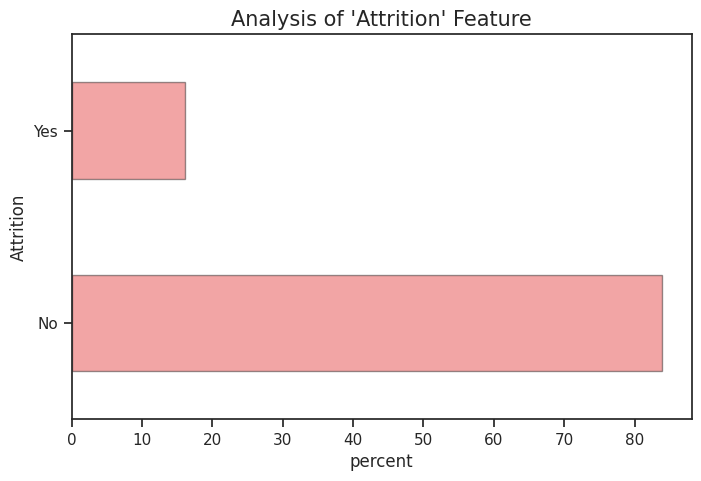


Total Numbers of Employee who 'not want to leave the company': 	 1233
Total Numbers of Employee who 'want to leave the company': 	 237 




In [5]:
# =================== EDA(Exploratary Data Analysis) on "Attrition" =================

sns.set(style = "ticks")

plt.figure(figsize = (8,5))

plt.title("Analysis of 'Attrition' Feature",fontsize = 15)


sns.countplot(y = "Attrition",data = data,color = "red",edgecolor = "black",width = 0.5,stat = "percent",alpha = 0.4)
plt.show()

print("\nTotal Numbers of Employee who 'not want to leave the company': \t",data["Attrition"].value_counts().iloc[0])
print("Total Numbers of Employee who 'want to leave the company': \t",data["Attrition"].value_counts().iloc[1],"\n\n")


#  I hypothesize that employee attrition was influnced by: Age , MaritalStatus , DistanceFromHome ,
                                                          #  MonthlyIncome , JobRole , EnvironmentSatisfaction ,
                                                          #  NumCompaniesWorked , Department


## Data Insights from "Attrition and Job_Role Feature"

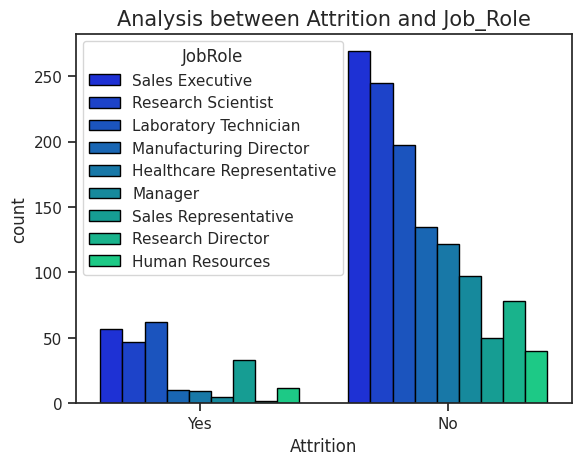


According to Data , Company should focus on "Sales Representative" job role
due to approx 50 percent of "Sales Representative" Employees want to leave the company.
Whereas the Others job role there was not a major percent of leaving the company.




In [6]:
# =================== Data Insights from "Attrition and Job_Role Feature" ======================


plt.title("Analysis between Attrition and Job_Role",fontsize = 15)


sns.countplot(x = "Attrition",data = data,hue = "JobRole",palette = "winter",edgecolor = "black",stat = "count")
plt.show()

print("""\nAccording to Data , Company should focus on "Sales Representative" job role
due to approx 50 percent of "Sales Representative" Employees want to leave the company.
Whereas the Others job role there was not a major percent of leaving the company.\n\n""")


## Analysis between "Attrition and Marital_Status"

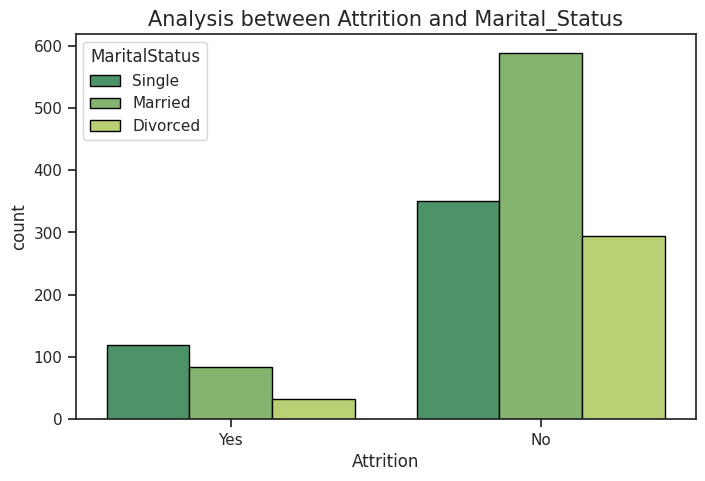


According to Data, Maritial Status was 'not a major factor' for Employees to leave the Company.


In [8]:
# ==================== Analysis between "Attrition and Marital_Status" ========================

plt.figure(figsize = (8,5))

plt.title("Analysis between Attrition and Marital_Status",fontsize = 15)


sns.countplot(x = "Attrition",data = data,hue = "MaritalStatus",palette = "summer",edgecolor = "black")
plt.show()

print("\nAccording to Data, Maritial Status was 'not a major factor' for Employees to leave the Company.")


## Comparision between "Attrition and Department"

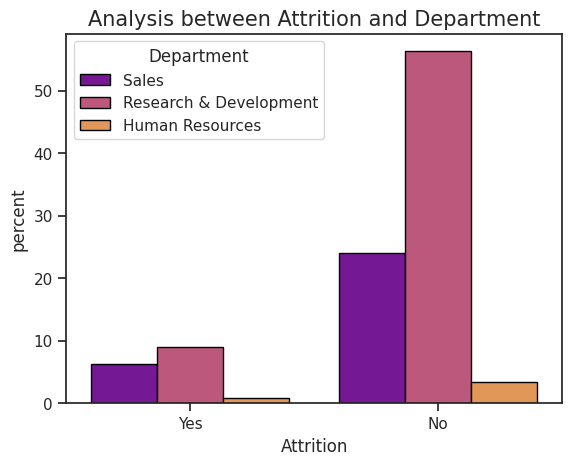


The Comapny should focus on the Sales Department due to according to data
form Sales Department approx 25 to 30 percent of Employees want to leave the Comapny.




In [9]:
# ==================== Comparision between "Attrition and Department" ========================

plt.title("Analysis between Attrition and Department",fontsize = 15)

sns.countplot(x = "Attrition",data = data,hue = "Department",palette = "plasma",stat = "percent",edgecolor = "black")
plt.show()

print("""\nThe Company should focus on the Sales Department due to according to data
form Sales Department approx 25 to 30 percent of Employees want to leave the Company.\n\n""")


## Analysis Between "Attrition and Distance_From_Home"

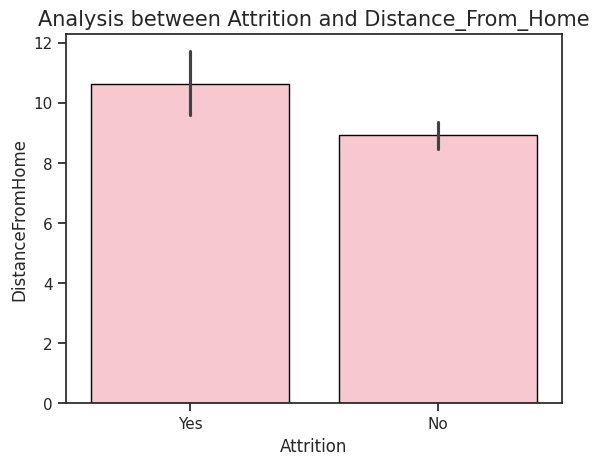


Those Employess who having more distance from their home were like to leave the company.
Company should assign as remote work to those employees who having more distance from their home




In [10]:
# ================= Analysis Between "Attrition and Distance_From_Home" ========================


plt.title("Analysis between Attrition and Distance_From_Home",fontsize = 15)


sns.barplot(x = "Attrition",y = "DistanceFromHome",data = data,color = "pink",estimator = "mean",edgecolor = "black")
plt.show()


print( """\nThose Employees who having more distance from their home were like to leave the company.
Company should assign as remote work to those employees who having more distance from their home\n\n""")



## Analysis between "Attrition and Monthly_Income"

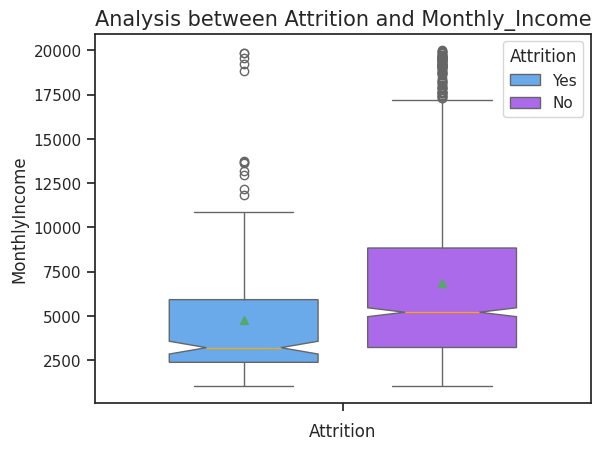


Those Employees like to leave the company were who getting less/lower monthly salary.
Company should increse the monthly salary for those who having less monthly salary and also company wanted to them.




In [11]:
# ================= Analysis between "Attrition and Monthly_Income" =====================

plt.title("Analysis between Attrition and Monthly_Income",fontsize = 15)

plt.xlabel("Attrition")

sns.boxplot(y = "MonthlyIncome",data = data,hue = "Attrition",palette = "cool",notch = True,showmeans = True,widths = 0.3,medianprops = dict(color = "orange",linewidth = 0.9))
plt.show()

print("""\nThose Employees like to leave the company were who getting less/lower monthly salary.
Company should increase the monthly salary for those who having less monthly salary and also company wanted to them.\n\n""")



## Comparison between "Attrition and Environment_Satisfaction"

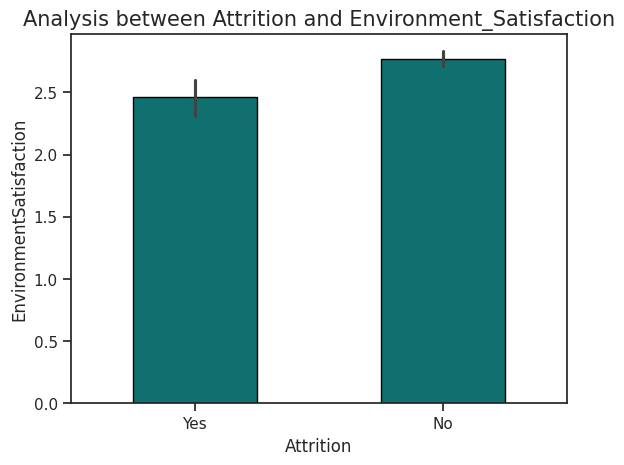


Those Employees who are not satisfy with their surrounding environment were like to leave the company.
Company should take care and make improvement on the surrounding environment.




In [12]:
# ================= Comaprision between "Attrition and Environment_Satisfaction" =====================

plt.title("Analysis between Attrition and Environment_Satisfaction",fontsize = 15)


sns.barplot(x = "Attrition",y = "EnvironmentSatisfaction",data = data,estimator = np.mean,errorbar = "ci",color = "teal",edgecolor = "black",width = 0.5)
plt.show()


print("""\nThose Employees who are not satisfy with their surrounding environment were like to leave the company.
Company should take care and make improvement on the surrounding environment.\n\n""")


## Data Insights from "Attrition and Years_At_Company"

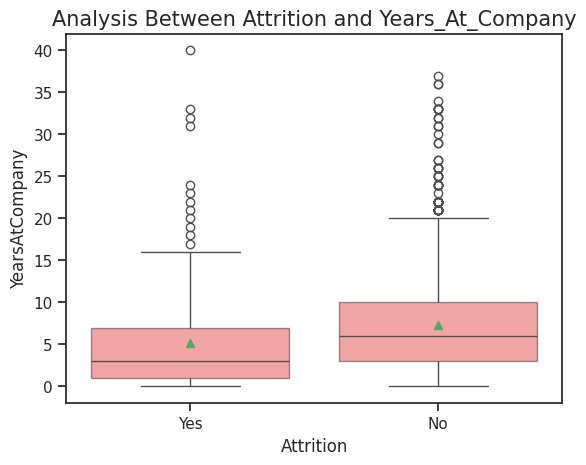


According to Data, Most of the New Employees were like to leave the company.
Company should focus on Young Employees and ask them to 'why they want to leave the company ?' and
focus on major issue for them.




In [13]:
# ================= Data Insights from "Attrition and Years_At_Company" =====================


plt.title("Analysis Between Attrition and Years_At_Company",fontsize = 15)

sns.boxplot(x = "Attrition",y = "YearsAtCompany",data = data,color = "red",boxprops = dict(alpha = 0.4,edgecolor = "black"),showmeans = True)
plt.show()

print("""\nAccording to Data, Most of the New Employees were like to leave the company.
Company should focus on Young Employees and ask them to 'why they want to leave the company ?' and
focus on major issue for them.\n\n""")


##  Data Encoding

In [14]:
# ==================================== Data Encoding ===================================


for val in data.select_dtypes(include = "object").columns:
  data[val] = data[val].astype("category")

print(data.dtypes)

data = pd.get_dummies(data,columns = data.select_dtypes(include = "category").columns,drop_first = True)
# print(data.columns)


Age                            int64
Attrition                   category
BusinessTravel              category
DailyRate                      int64
Department                  category
DistanceFromHome               int64
Education                      int64
EducationField              category
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                      category
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                     category
JobSatisfaction                int64
MaritalStatus               category
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                      category
OverTime                    category
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
S

## Data Selection

In [15]:
# ==================================== Data Selection ===================================

# After Data Encoding,
#  "Attrition" feature name were changes to "Attrition_Yes"

X = data.drop("Attrition_Yes",axis = 1)

y = data["Attrition_Yes"]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.4, random_state=42)


## Data Prediction

In [17]:
# ==================================== Data Prediction ===================================


model = LogisticRegression(class_weight = "balanced",solver = "sag",max_iter = 10000,random_state = 42)

train = model.fit(X_train,y_train)

pred_data = model.predict(X_test)
pred_data1 = model.predict_proba(X_test)
print(pred_data)

pred_score = accuracy_score(y_test,pred_data)
print("\nAccuracy of Predicted Data in percent: \n",pred_score*100)


cm = confusion_matrix(y_test,pred_data)
print("\nModel Prediction Report: \n", pd.DataFrame(dict(Predicted_Stay = cm[0],
                                                       Predicted_Leave = cm[1]),index = ["Actual_Stay","Actual_Leave"]))

cr = classification_report(y_test,pred_data)
print("\n",cr)


[[0.6008794  0.3991206 ]
 [0.38840335 0.61159665]
 [0.49572518 0.50427482]
 ...
 [0.55416997 0.44583003]
 [0.59094501 0.40905499]
 [0.81890609 0.18109391]]

Accuracy of Predicted Data in percent: 
 52.60770975056689

Model Prediction Report: 
               Predicted_Stay  Predicted_Leave
Actual_Stay              358               50
Actual_Leave             368              106

               precision    recall  f1-score   support

       False       0.88      0.49      0.63       726
        True       0.22      0.68      0.34       156

    accuracy                           0.53       882
   macro avg       0.55      0.59      0.48       882
weighted avg       0.76      0.53      0.58       882

